In [1]:
import os
import torch
import argparse
import pandas as pd
import numpy as np
import seaborn as sns
from collections import Counter
from functools import partial
from torch import nn, optim
from matplotlib import pyplot as plt

from utils import sort_genes
from dl_utils import *

## load data of OMIX002254

In [2]:
data_dir = "../data/batch_data/"
info_path = os.path.join(data_dir, "OMIX002254_studydesign.csv")
data_path = os.path.join(data_dir, "OMIX002254-01.csv")
info_df = pd.read_csv(info_path, sep = ",")
info_df["sequencing_id"] = info_df["sequencing_id"].apply(lambda x: x[21:])
info_df.head()

,biospecimen_name,file_name,submitter_id,data_category,family_id,sequencing_id,pedigree,site,preperation_method,collection_date,...,project_name,extraction_protocol,project_description,platform,investigator_name,key,path,access,project,annotations
0,D5,Quartet_RNA_P_BGI_L3_B1_D5_1_count_v1.csv,PGx,RNA-seq Transcriptomics,Q2,P_BGI_L3_B1_D5_1,daughter,BGI,PolyA,2016/4/26,...,The Quartet Project for Quality Control of Mul...,TRIzol; QIAGEN RNeasy Maxi Kit,The Quartet Project aims to provide resources ...,BGI,Leming SHI;Yuanting ZHENG;Ying YU; Zhenqiang Su,Quartet_RNA_P_BGI_L3_B1_D5_1_count_v1.csv,https://www.biosino.org/download/node/data/OED...,Public,The Quartet Project for Quality Control of Mul...,NaN
1,D5,Quartet_RNA_P_BGI_L3_B1_D5_2_count_v1.csv,PGx,RNA-seq Transcriptomics,Q2,P_BGI_L3_B1_D5_2,daughter,BGI,PolyA,2016/4/26,...,The Quartet Project for Quality Control of Mul...,TRIzol; QIAGEN RNeasy Maxi Kit,The Quartet Project aims to provide resources ...,BGI,Leming SHI;Yuanting ZHENG;Ying YU; Zhenqiang Su,Quartet_RNA_P_BGI_L3_B1_D5_2_count_v1.csv,https://www.biosino.org/download/node/data/OED...,Public,The Quartet Project for Quality Control of Mul...,NaN
2,D5,Quartet_RNA_P_BGI_L3_B1_D5_3_count_v1.csv,PGx,RNA-seq Transcriptomics,Q2,P_BGI_L3_B1_D5_3,daughter,BGI,PolyA,2016/4/26,...,The Quartet Project for Quality Control of Mul...,TRIzol; QIAGEN RNeasy Maxi Kit,The Quartet Project aims to provide resources ...,BGI,Leming SHI;Yuanting ZHENG;Ying YU; Zhenqiang Su,Quartet_RNA_P_BGI_L3_B1_D5_3_count_v1.csv,https://www.biosino.org/download/node/data/OED...,Public,The Quartet Project for Quality Control of Mul...,NaN
3,D5,Quartet_RNA_P_BGI_L6_B1_D5_1_count_v1.csv,PGx,RNA-seq Transcriptomics,Q2,P_BGI_L6_B1_D5_1,daughter,VAZ,PolyA,2016/4/26,...,The Quartet Project for Quality Control of Mul...,TRIzol; QIAGEN RNeasy Maxi Kit,The Quartet Project aims to provide resources ...,BGI,Leming SHI;Yuanting ZHENG;Ying YU; Zhenqiang Su,Quartet_RNA_P_BGI_L6_B1_D5_1_count_v1.csv,https://www.biosino.org/download/node/data/OED...,Public,The Quartet Project for Quality Control of Mul...,NaN
4,D5,Quartet_RNA_P_BGI_L6_B1_D5_2_count_v1.csv,PGx,RNA-seq Transcriptomics,Q2,P_BGI_L6_B1_D5_2,daughter,VAZ,PolyA,2016/4/26,...,The Quartet Project for Quality Control of Mul...,TRIzol; QIAGEN RNeasy Maxi Kit,The Quartet Project aims to provide resources ...,BGI,Leming SHI;Yuanting ZHENG;Ying YU; Zhenqiang Su,Quartet_RNA_P_BGI_L6_B1_D5_2_count_v1.csv,https://www.biosino.org/download/node/data/OED...,Public,The Quartet Project for Quality Control of Mul...,NaN


In [3]:
data_raw = pd.read_csv(data_path, sep = ",").transpose()
data_raw.columns = data_raw.iloc[0]
data_raw = data_raw.iloc[1:]
data_raw.reset_index(inplace = True)
data_raw.rename({"index": "ID"}, axis = 1, inplace = True)
data_raw.head()

Unnamed: 0,ID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000285480,ENSG00000285483,ENSG00000285486,ENSG00000285491,ENSG00000285492,ENSG00000285498,ENSG00000285505,ENSG00000285508,ENSG00000285509,ENSG00000285513
0,P_BGI_L3_B1_D5_1,3,0,4020,4327,1043,9280,0,3332,2582,...,4,0,0,0,0,0,0,0,16,0
1,P_BGI_L3_B1_D5_2,0,0,3975,3317,795,9489,0,3069,2395,...,4,0,0,0,0,0,0,0,7,0
2,P_BGI_L3_B1_D5_3,0,0,6668,6429,1556,14895,6,4870,4374,...,4,0,6,0,0,0,0,0,63,0
3,P_BGI_L3_B1_D6_1,2,0,4040,2751,746,23499,0,4444,1918,...,4,0,0,0,0,0,0,0,89,0
4,P_BGI_L3_B1_D6_2,0,0,3965,2758,958,23579,0,4366,2041,...,8,0,0,0,1,0,0,0,12,0


In [4]:
ids = data_raw.pop("ID").values.squeeze()
batches = [info_df[info_df["sequencing_id"] == id_]["batch"].values[0] for id_ in ids]
donors = [info_df[info_df["sequencing_id"] == id_]["biospecimen_name"].values[0] for id_ in ids]
labs = [info_df[info_df["sequencing_id"] == id_]["site"].values[0] for id_ in ids]
protocols = [info_df[info_df["sequencing_id"] == id_]["preperation_method"].values[0] for id_ in ids]
devices = [info_df[info_df["sequencing_id"] == id_]["platform"].values[0] for id_ in ids]
len(set(ids)), len(set(batches)), len(set(donors)), len(set(labs)), len(set(protocols)), len(set(devices))

(252, 21, 4, 8, 2, 2)

In [5]:
data_raw.head()

Unnamed: 0,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000285480,ENSG00000285483,ENSG00000285486,ENSG00000285491,ENSG00000285492,ENSG00000285498,ENSG00000285505,ENSG00000285508,ENSG00000285509,ENSG00000285513
0,3,0,4020,4327,1043,9280,0,3332,2582,4856,...,4,0,0,0,0,0,0,0,16,0
1,0,0,3975,3317,795,9489,0,3069,2395,4615,...,4,0,0,0,0,0,0,0,7,0
2,0,0,6668,6429,1556,14895,6,4870,4374,7246,...,4,0,6,0,0,0,0,0,63,0
3,2,0,4040,2751,746,23499,0,4444,1918,4331,...,4,0,0,0,0,0,0,0,89,0
4,0,0,3965,2758,958,23579,0,4366,2041,3932,...,8,0,0,0,1,0,0,0,12,0


## sample normalization

In [6]:
data_sum = np.expand_dims(data_raw.sum(axis = 1).values, axis = 1)
data_raw = data_raw / data_sum * 10000.
data_raw.head()

Unnamed: 0,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000285480,ENSG00000285483,ENSG00000285486,ENSG00000285491,ENSG00000285492,ENSG00000285498,ENSG00000285505,ENSG00000285508,ENSG00000285509,ENSG00000285513
0,0.000334,0.0,0.447955,0.482165,0.116223,1.034085,0.0,0.37129,0.287716,0.541112,...,0.000446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001783,0.0
1,0.0,0.0,0.456232,0.38071,0.091246,1.089102,0.0,0.352245,0.274887,0.529688,...,0.000459,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000803,0.0
2,0.0,0.0,0.481147,0.463901,0.112277,1.074788,0.000433,0.351408,0.315617,0.522854,...,0.000289,0.0,0.000433,0.0,0.0,0.0,0.0,0.0,0.004546,0.0
3,0.000225,0.0,0.453792,0.309005,0.083794,2.639517,0.0,0.499171,0.215439,0.486478,...,0.000449,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.009997,0.0
4,0.0,0.0,0.462849,0.321951,0.111831,2.752463,0.0,0.509659,0.238253,0.458997,...,0.000934,0.0,0.0,0.0,0.000117,0.0,0.0,0.0,0.001401,0.0


## sort genes with intensities

In [7]:
sorted_cols = sort_genes(data_raw)
raw_data = data_raw[sorted_cols]
raw_data.head()

Unnamed: 0,ENSG00000129816,ENSG00000260575,ENSG00000260590,ENSG00000260622,ENSG00000227635,ENSG00000260827,ENSG00000260854,ENSG00000260864,ENSG00000227444,ENSG00000227439,...,ENSG00000277027,ENSG00000111640,ENSG00000251562,ENSG00000167658,ENSG00000198804,ENSG00000156508,ENSG00000210082,ENSG00000283293,ENSG00000274012,ENSG00000276168
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001114,40.513636,1.075204,65.974867,121.225445,137.810369,56.436433,0.01404,0.703022,0.345327
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001377,41.476447,0.885032,71.343722,115.890063,135.286162,49.932858,0.016872,0.524408,0.289119
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0057,39.53653,1.091456,69.339069,122.215594,135.493679,52.859207,0.08861,1.029689,0.568819
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001236,34.580723,4.403913,47.111439,76.100078,134.789719,46.382676,0.037516,0.565667,0.331245
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.005837,36.479149,4.544558,48.480535,79.157671,126.713676,46.474818,0.039573,0.467752,0.28985


## data preprocessing: logrithm transformation

In [8]:
raw_data_plus_1 = raw_data.values + 1
raw_data_plus_1 = raw_data_plus_1.astype("float64")
data = np.log(raw_data_plus_1)

## onehot transformation of batches

In [9]:
bat2label = {b:i for i, b in enumerate(sorted(set(batches)))}
label2bat = {i:b for i, b in enumerate(sorted(set(batches)))}
labels = np.array([bat2label[t] for t in batches])
labels_onehot = transform_hot(labels)
bat2label

{'P_BGI_L3_B1': 0,
 'P_BGI_L6_B1': 1,
 'P_ILM_L1_B1': 2,
 'P_ILM_L2_B1': 3,
 'P_ILM_L5_B1': 4,
 'P_ILM_L6_B1': 5,
 'P_ILM_L8_B1': 6,
 'R_BGI_L3_B1': 7,
 'R_BGI_L6_B1': 8,
 'R_BGI_L7_B1': 9,
 'R_ILM_L1_B1': 10,
 'R_ILM_L2_B1': 11,
 'R_ILM_L2_B2': 12,
 'R_ILM_L4_B1': 13,
 'R_ILM_L4_B2': 14,
 'R_ILM_L4_B3': 15,
 'R_ILM_L5_B1': 16,
 'R_ILM_L5_B2': 17,
 'R_ILM_L5_B3': 18,
 'R_ILM_L6_B1': 19,
 'R_ILM_L8_B1': 20}

## model paths

In [10]:
db_name = "Quartet"
model_dir = f"../models/batch-{db_name}/"
out_dir = os.path.join(model_dir, f"test_{db_name}"); os.makedirs(out_dir, exist_ok = True)

## train & val & test for Quartet

In [11]:
rng = np.random.RandomState(0)
all_ids = np.arange(len(data))
all_idxs = np.arange(len(data))
rng.shuffle(all_idxs)

tot_train_val_idxs = rng.choice(all_idxs, size = int(0.8*len(all_idxs)), replace = False)
tot_test_idxs = np.array([t for t in all_idxs if t not in tot_train_val_idxs])
tot_val_idxs = rng.choice(tot_train_val_idxs, size = int(0.2*len(tot_train_val_idxs)), replace = False)
tot_train_idxs = np.array([t for t in tot_train_val_idxs if t not in tot_val_idxs])

train_data, train_labels, train_labels_hot = data[tot_train_idxs], labels[tot_train_idxs], labels_onehot[tot_train_idxs]
val_data, val_labels, val_labels_hot = data[tot_val_idxs], labels[tot_val_idxs], labels_onehot[tot_val_idxs]
test_data, test_labels, test_labels_hot= data[tot_test_idxs], labels[tot_test_idxs], labels_onehot[tot_test_idxs]
train_ids, val_ids, test_ids = ids[tot_train_idxs], ids[tot_val_idxs], ids[tot_test_idxs]
print(train_data.shape, train_labels_hot.shape)
print(val_data.shape, val_labels_hot.shape)
print(test_data.shape, test_labels_hot.shape)

(161, 58395) (161, 21)
(40, 58395) (40, 21)
(51, 58395) (51, 21)


## network parameters setting

In [12]:
in_dim = raw_data.shape[1]
num_platform = len(bat2label)
batch_size = 256 ##256
hidden_dim = 256
z_dim = 128
drop = 0.3

ae = AE(in_dim, hidden_dim, num_platform, z_dim, drop).cuda()
ae.apply(weight_init)
net_param(ae)

30.460699

## load trained model & test

In [13]:
ae_sd = torch.load(os.path.join(model_dir, "ae.tar"))            
ae.load_state_dict(ae_sd)
ae.eval()

AE(
  (enc): Sequential(
    (0): Linear(in_features=58395, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.01)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=256, out_features=256, bias=True)
    (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): LeakyReLU(negative_slope=0.01)
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=256, out_featu

In [14]:
sample_num = len(data)
iteration = int(np.ceil(sample_num/batch_size))
normed_data = np.ones_like(data)
for i in range(iteration):
    start = i*batch_size
    end = start + batch_size
    if end > sample_num: end = sample_num

    b_data = torch.FloatTensor(data[start:end]).cuda()
    rec_x = ae.dec(ae.enc(b_data))
    normed_data[start:end] = rec_x.detach().cpu().numpy()


## decomposition analysis

/data2/DeepAI/Zhangmj/miniconda3/envs/pytorch/lib/python3.10/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/data2/DeepAI/Zhangmj/miniconda3/envs/pytorch/lib/python3.10/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/data2/DeepAI/Zhangmj/miniconda3/envs/pytorch/li

../models/batch-Quartet/test_Quartet/umap_raw_Quartet.png 0.30729166666666663 0.34620578060506035 0.5843677748620263
../models/batch-Quartet/test_Quartet/umap_aligned_Quartet.png 0.7406249999999998 0.7464041797210145 0.7309858635868779


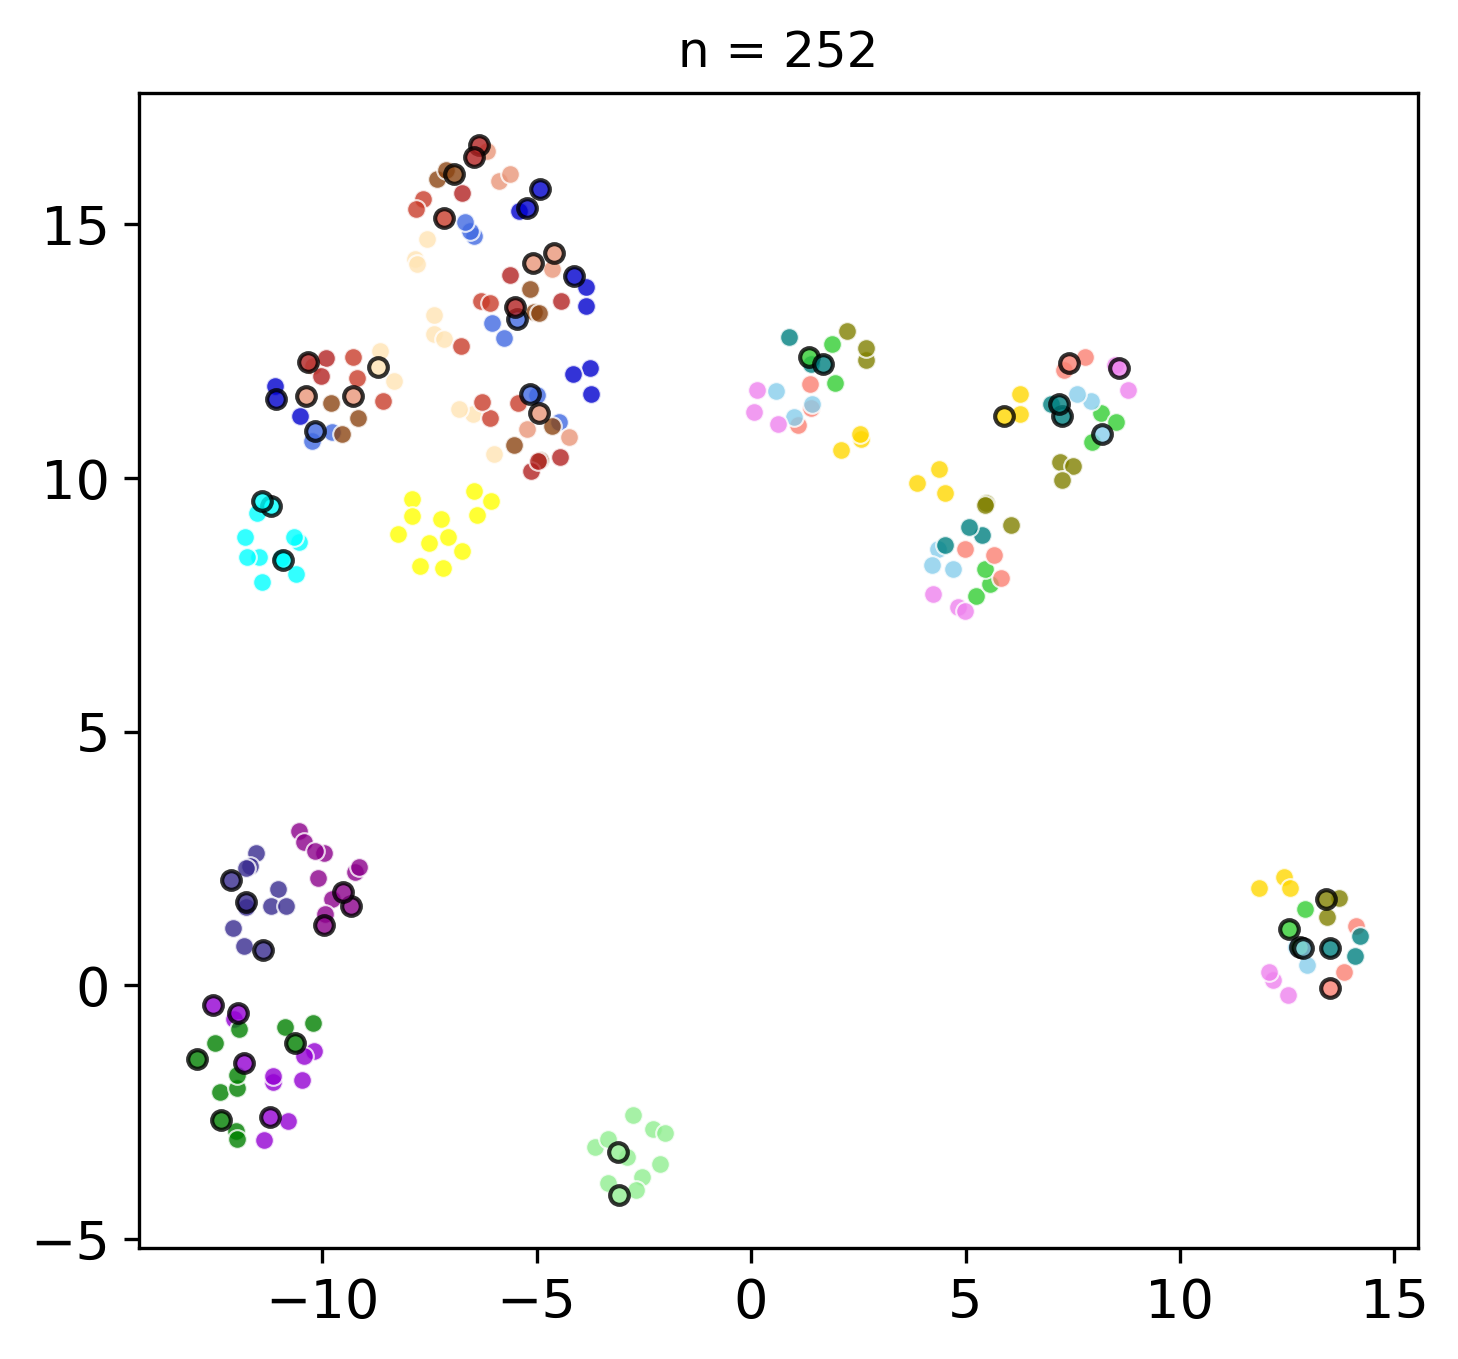

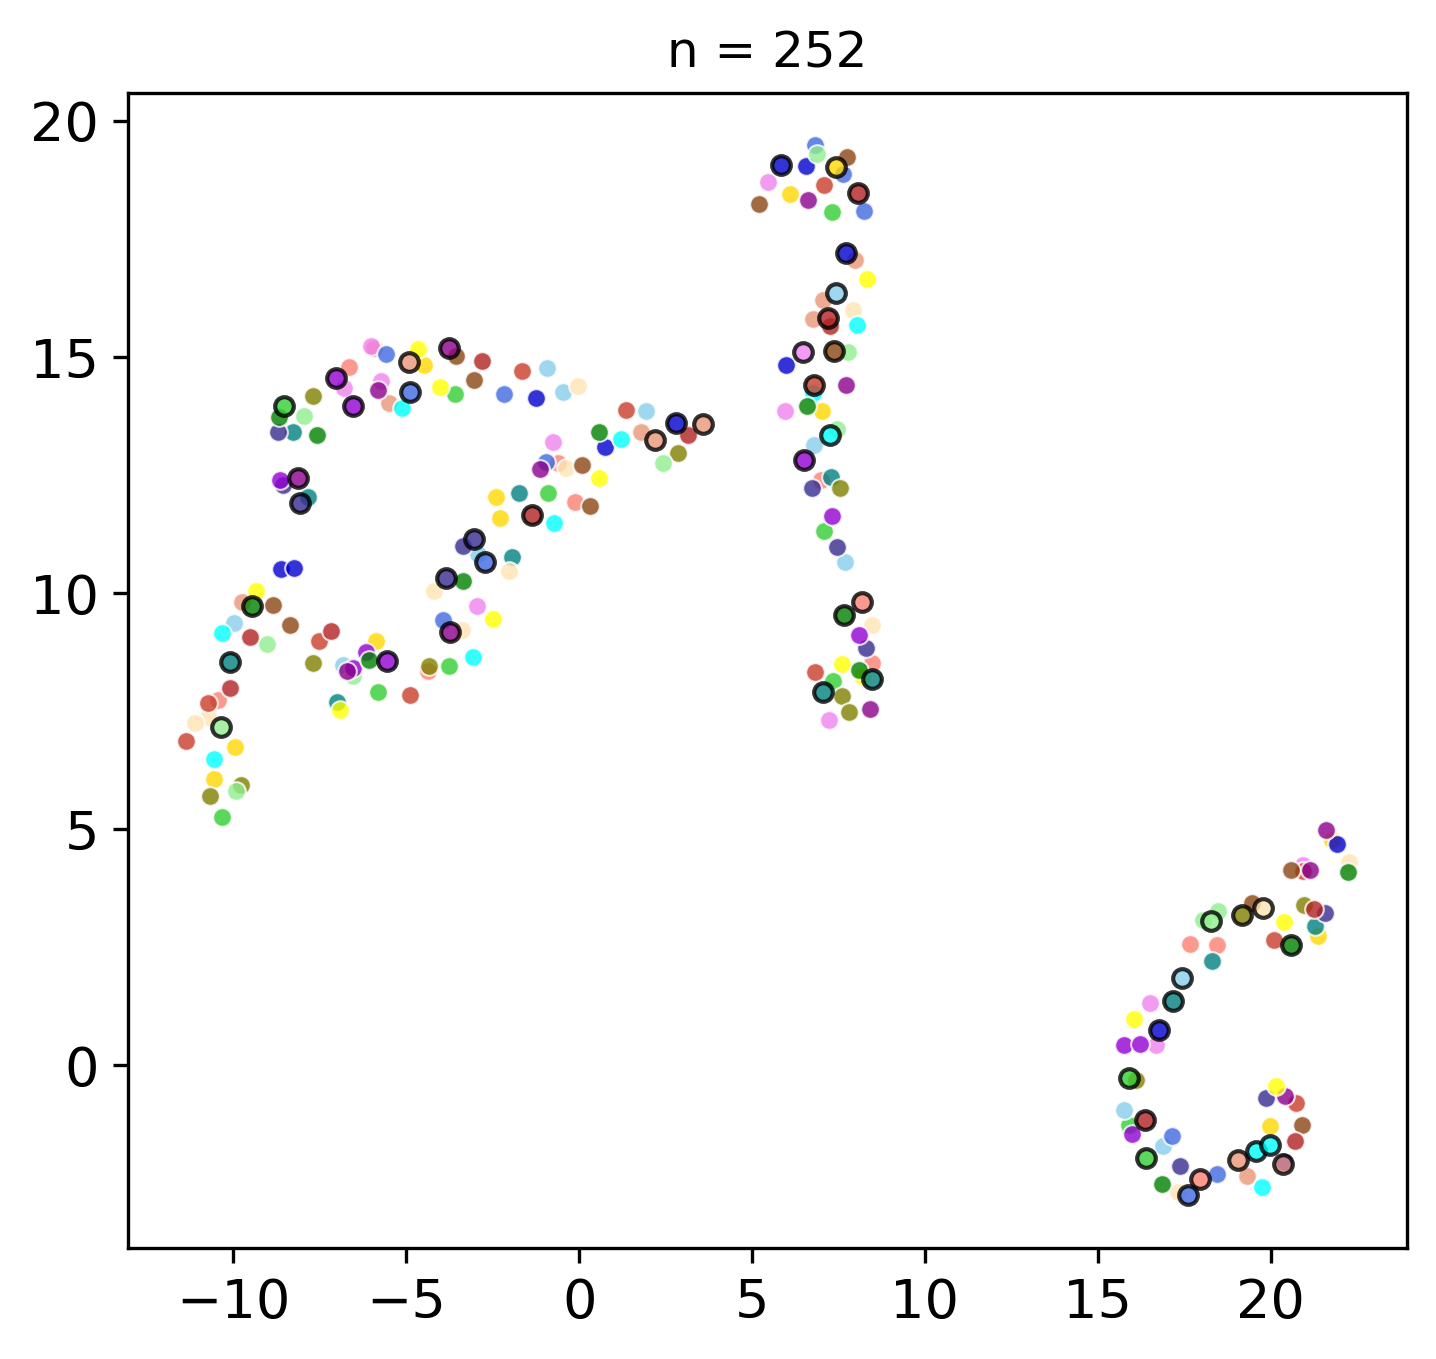

In [15]:
import matplotlib
import decomposition_utils as DPU
from importlib import reload
reload(DPU)

fitter = "umap"

colors = ["limegreen", "salmon", "skyblue", "violet", "gold", "teal", "olive"]
import matplotlib
tot_colors = list(matplotlib.colors.cnames.keys())

while len(colors) < len(bat2label):
    c = rng.choice(tot_colors, 1)[0]
    if c not in colors:
        colors.append(c)
colors = colors[:len(bat2label)]
colors[10] = "#C93C2A"
colors[14] = "#372A8F"

trans_raw = DPU.decom_plot(
    data, labels, tot_train_val_idxs, tot_test_idxs, 
    os.path.join(out_dir, f"{fitter}_raw_{db_name}.png"), colors = colors, title = db_name,
    label2name = label2bat, fitter = fitter)

trans_aligned = DPU.decom_plot(
    normed_data, labels, tot_train_val_idxs, tot_test_idxs, 
    os.path.join(out_dir, f"{fitter}_aligned_{db_name}.png"), colors = colors, title = db_name, 
    label2name = label2bat, fitter = fitter)

../models/batch-Quartet/test_Quartet/umap_raw_Quartet.png 0.13888888888888887 0.15968146461350452 0.3040674603174604
../models/batch-Quartet/test_Quartet/umap_aligned_Quartet.png 0.0224867724867725 0.02680893386437347 0.018154761904761892


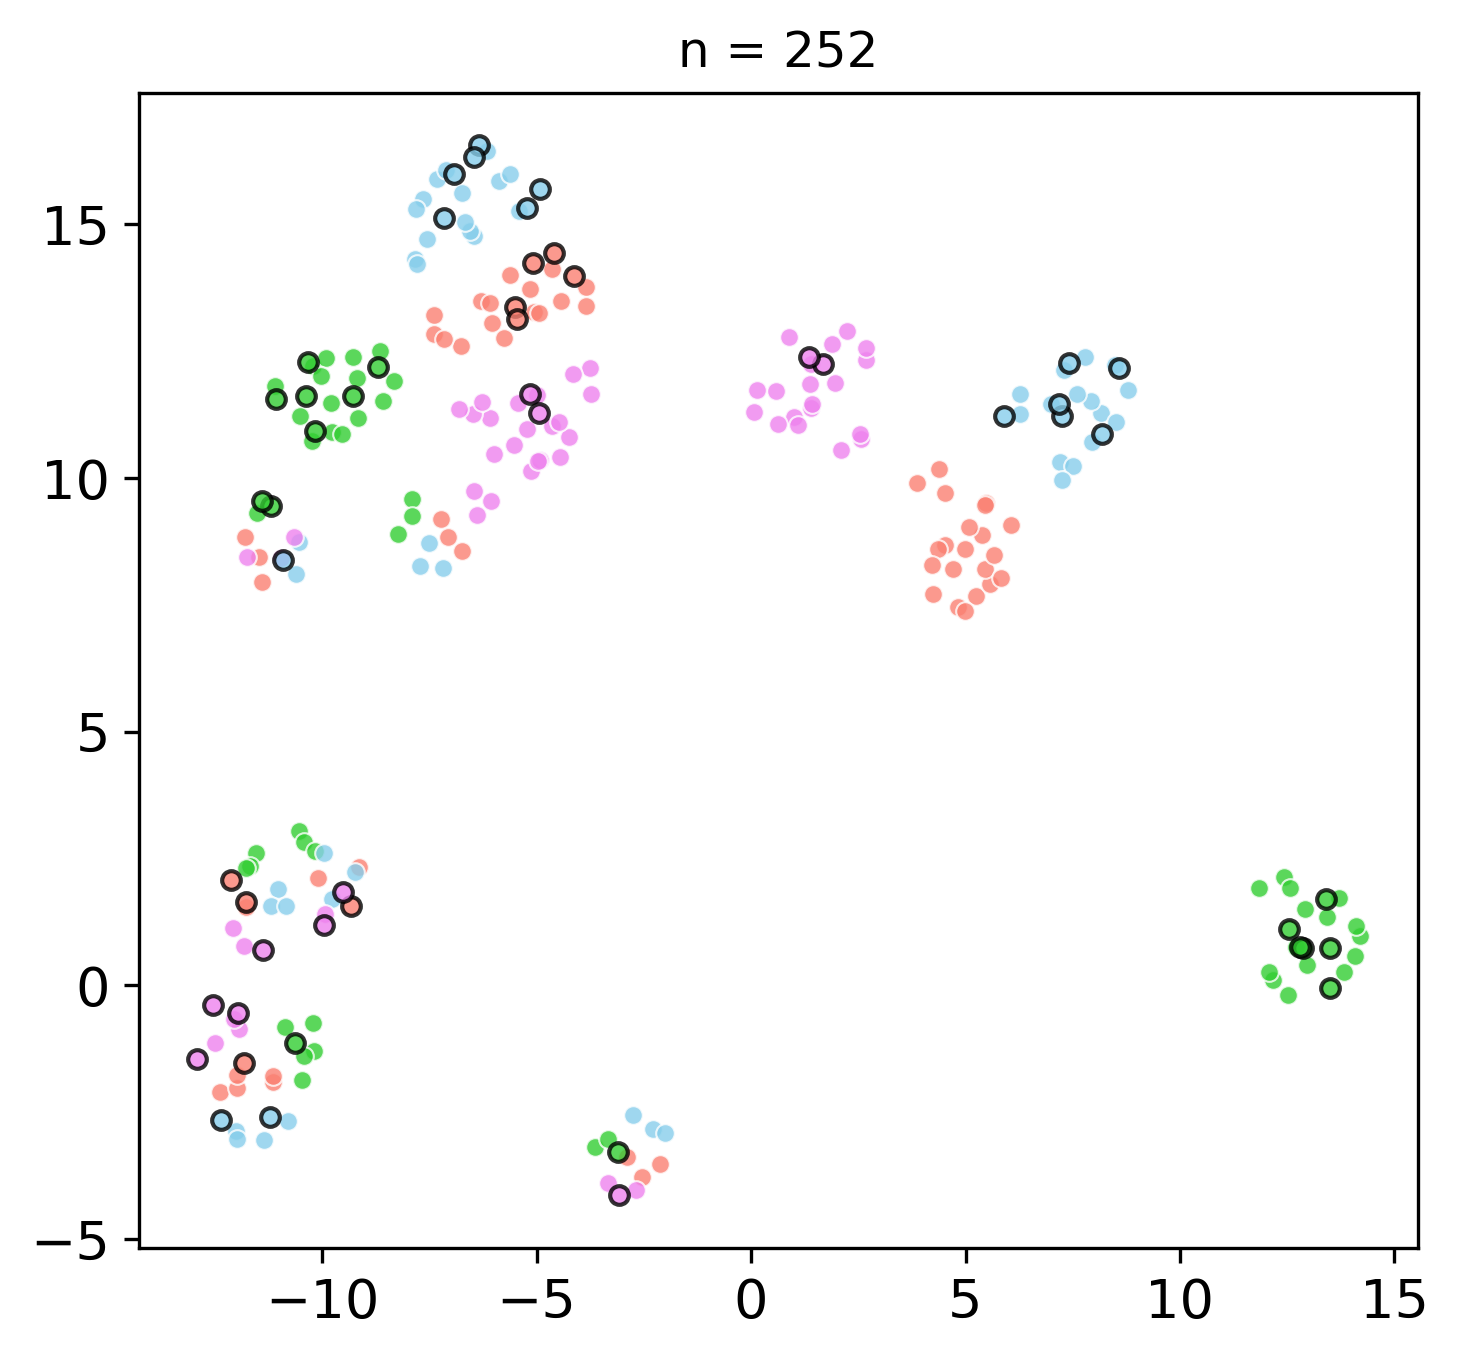

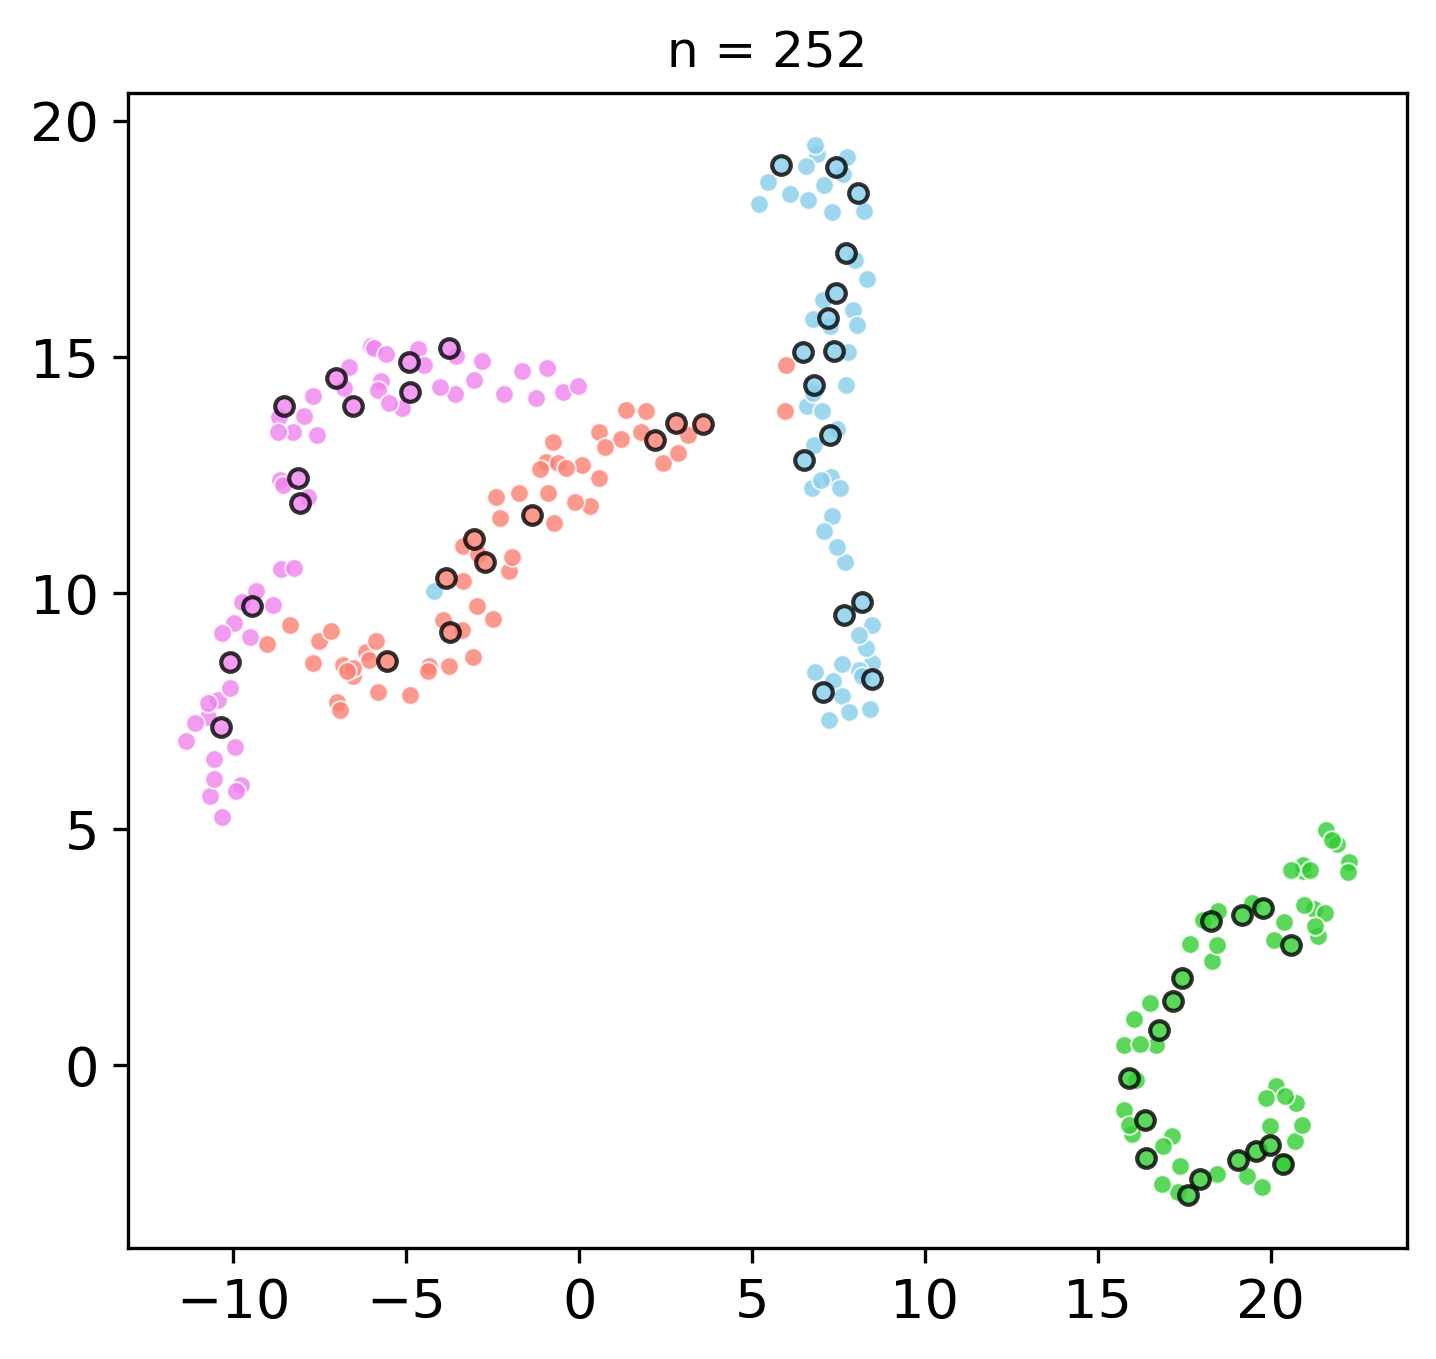

In [16]:
donors = np.array(donors)
trans_raw = DPU.decom_plot(
    data, donors, tot_train_val_idxs, tot_test_idxs, 
    os.path.join(out_dir, f"{fitter}_raw_{db_name}.png"), colors = colors, title = db_name,
    label2name = {d: i for i, d in enumerate(sorted(set(donors)))}, fitter = fitter)

trans_aligned = DPU.decom_plot(
    normed_data, donors, tot_train_val_idxs, tot_test_idxs, 
    os.path.join(out_dir, f"{fitter}_aligned_{db_name}.png"), colors = colors, title = db_name, 
    label2name = {d: i for i, d in enumerate(sorted(set(donors)))}, fitter = fitter)